# Phase 2 sanity check: observed delay distribution

**Deliverable (ROADMAP.md, Phase 2):** a histogram of `observed_delay_s` from the
curated `arrivals` layer. If the pipeline is deriving ground truth correctly, it
should *look like* a transit delay distribution:

- mode slightly positive (buses are usually a little late),
- long right tail (occasionally very late),
- some negative values (occasionally early).

**To regenerate:** with the Docker stack running and the stream processor
accumulating arrivals —

```bash
uv run jupyter nbconvert --to notebook --execute --inplace notebooks/arrivals_sanity_check.ipynb
```

In [1]:
"""Load every arrivals Parquet file from MinIO into one DataFrame."""

import io
import os

import boto3
import pandas as pd
from botocore.config import Config

ENDPOINT = os.environ.get("MINIO_ENDPOINT", "http://localhost:9000")
ACCESS = os.environ.get("MINIO_ROOT_USER", "minioadmin")
SECRET = os.environ.get("MINIO_ROOT_PASSWORD", "minioadmin")
BUCKET = os.environ.get("CURATED_BUCKET", "transit-curated")
PREFIX = "curated/arrivals/"

s3 = boto3.client(
    "s3",
    endpoint_url=ENDPOINT,
    aws_access_key_id=ACCESS,
    aws_secret_access_key=SECRET,
    config=Config(signature_version="s3v4"),
)

frames = []
paginator = s3.get_paginator("list_objects_v2")
for page in paginator.paginate(Bucket=BUCKET, Prefix=PREFIX):
    for obj in page.get("Contents", []):
        key = obj["Key"]
        if not key.endswith(".parquet"):
            continue
        body = s3.get_object(Bucket=BUCKET, Key=key)["Body"].read()
        frame = pd.read_parquet(io.BytesIO(body))
        # Recover the partition column from the key: .../dt=YYYY-MM-DD/...
        frame["dt"] = key.split("dt=")[1].split("/")[0]
        frames.append(frame)

df = pd.concat(frames, ignore_index=True)
print(f"{len(df):,} arrivals from {len(frames)} Parquet files")
df.head()

4,138 arrivals from 7 Parquet files


,event_id,trip_id,route_id,stop_id,stop_sequence,scheduled_arrival_ts,observed_arrival_ts,observed_delay_s,observed_delay_imputed,day_of_week,hour_of_day,is_school_day,is_public_holiday,ingested_at,processed_at,dt
0,cba46832-fe86-5d81-b341-64166c20a936,37580323-SBL 26_27-42892,723-4843,300770,8,2026-07-11 05:29:00,2026-07-11 05:33:08,248,True,5,15,None,None,2026-07-11 05:35:13.669,2026-07-11 05:36:00.804908,2026-07-11
1,1d37cda3-1e75-54b7-ba60-9a72c3384fae,37600389-WBS 26_27-42909,524-4841,315180,7,2026-07-11 05:31:00,2026-07-11 05:33:20,140,True,5,15,None,None,2026-07-11 05:35:13.669,2026-07-11 05:36:00.804934,2026-07-11
2,c19ea49a-d3f9-57af-8f9c-ee4e0f24522c,37580442-SBL 26_27-42892,777-4843,321299,5,2026-07-11 05:37:00,2026-07-11 05:33:23,-217,False,5,15,None,None,2026-07-11 05:35:13.669,2026-07-11 05:36:00.804945,2026-07-11
3,20d1858b-3b4d-54ce-b540-1d2d3c8a799a,37693709-LCBS 26_27-43170,563-4916,312664,14,2026-07-11 05:33:00,2026-07-11 05:33:27,27,True,5,15,None,None,2026-07-11 05:35:13.669,2026-07-11 05:36:00.804953,2026-07-11
4,6a5bef38-4f78-5c7d-b083-702a5432ab1d,37600206-WBS 26_27-42909,509-4841,310565,3,2026-07-11 05:32:00,2026-07-11 05:33:16,76,False,5,15,None,None,2026-07-11 05:35:13.669,2026-07-11 05:36:00.804968,2026-07-11


In [2]:
"""Overview: volume, coverage, imputation share, quality bounds."""

observed = df[~df["observed_delay_imputed"]]

print(f"Arrivals total          : {len(df):,}")
print(f"  directly observed     : {len(observed):,} ({len(observed) / len(df):.0%})")
print(f"  imputed               : {df['observed_delay_imputed'].sum():,}")
print(f"Distinct trips          : {df['trip_id'].nunique():,}")
print(f"Distinct routes         : {df['route_id'].nunique():,}")
print(f"Distinct stops          : {df['stop_id'].nunique():,}")
print(f"Duplicate event_ids     : {df['event_id'].duplicated().sum():,}")
print(
    f"Time coverage           : {df['observed_arrival_ts'].min()} -> "
    f"{df['observed_arrival_ts'].max()}"
)

# docs/DATA.md quality gate: delays outside [-1800 s, +7200 s] are anomalies.
anomalous = df[(df["observed_delay_s"] < -1800) | (df["observed_delay_s"] > 7200)]
print(f"Outside [-30 min, +2 h] : {len(anomalous):,} ({len(anomalous) / len(df):.1%})")

df["observed_delay_s"].describe().round(1)

Arrivals total          : 4,138
  directly observed     : 567 (14%)
  imputed               : 3,571
Distinct trips          : 286
Distinct routes         : 135
Distinct stops          : 2,709
Duplicate event_ids     : 0
Time coverage           : 2026-07-11 04:57:48 -> 2026-07-11 05:37:37
Outside [-30 min, +2 h] : 18 (0.4%)


count    4138.0
mean      899.1
std       871.7
min     -4239.0
25%       243.0
50%       717.0
75%      1381.0
max      4323.0
Name: observed_delay_s, dtype: float64

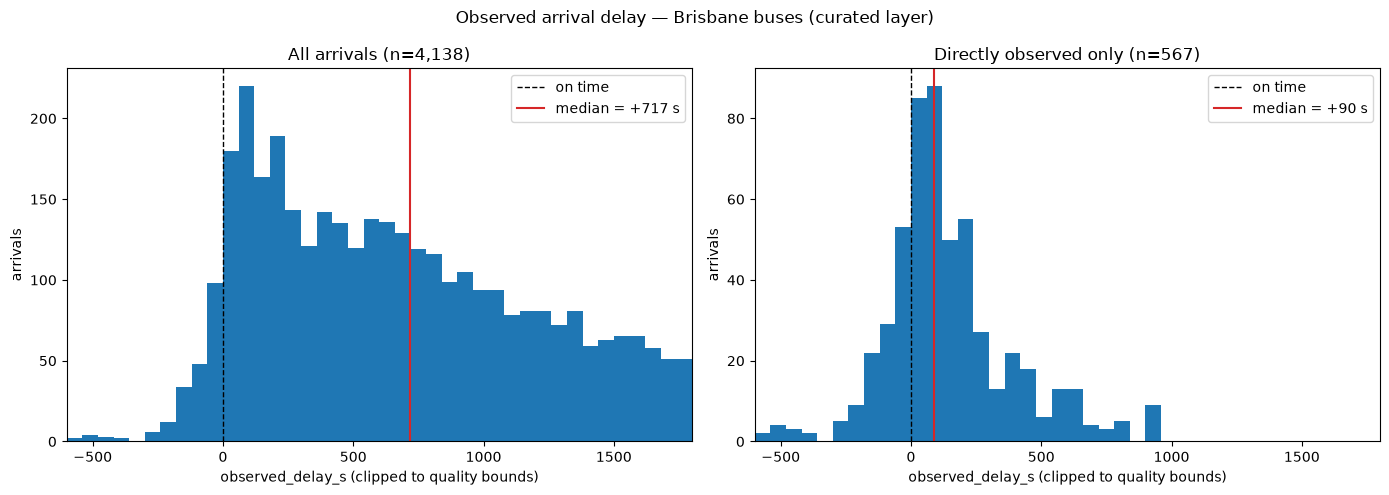

In [3]:
"""The deliverable: observed_delay_s histogram.

Two panels because imputed arrivals systematically overstate delay: when a
bus is first seen mid-route (pipeline cold start), all earlier stops get the
*current* record timestamp as their arrival time. The directly-observed panel
is the honest ground-truth signal the model will train on.
"""

import matplotlib.pyplot as plt

CLIP = (-1800, 7200)  # DATA.md quality bounds
bins = range(CLIP[0], CLIP[1] + 60, 60)  # one bar per minute

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, (frame, title) in zip(
    axes,
    [
        (df, f"All arrivals (n={len(df):,})"),
        (observed, f"Directly observed only (n={len(observed):,})"),
    ],
):
    data = frame["observed_delay_s"].clip(*CLIP)
    ax.hist(data, bins=bins, edgecolor="none")
    ax.axvline(0, color="black", linewidth=1, linestyle="--", label="on time")
    ax.axvline(
        data.median(),
        color="tab:red",
        linewidth=1.5,
        label=f"median = {data.median():+.0f} s",
    )
    ax.set_xlim(-600, 1800)  # zoom on [-10 min, +30 min] where the mass is
    ax.set_xlabel("observed_delay_s (clipped to quality bounds)")
    ax.set_ylabel("arrivals")
    ax.set_title(title)
    ax.legend()

fig.suptitle("Observed arrival delay — Brisbane buses (curated layer)")
fig.tight_layout()
plt.show()

**What to look for.** A healthy transit delay distribution has its mode a bit
right of zero, a long right tail, and a modest early-arrival shoulder left of
zero. Two failure signatures would indicate pipeline bugs rather than reality:
a spike exactly at 0 (schedule echo — comparing the schedule with itself) or a
distribution centred hours away from zero (service-date resolution errors,
e.g. night buses matched to the wrong day).

,median_delay_s,n
hour_of_day,,
14,2554.0,2
15,91.0,560
16,-3310.0,5


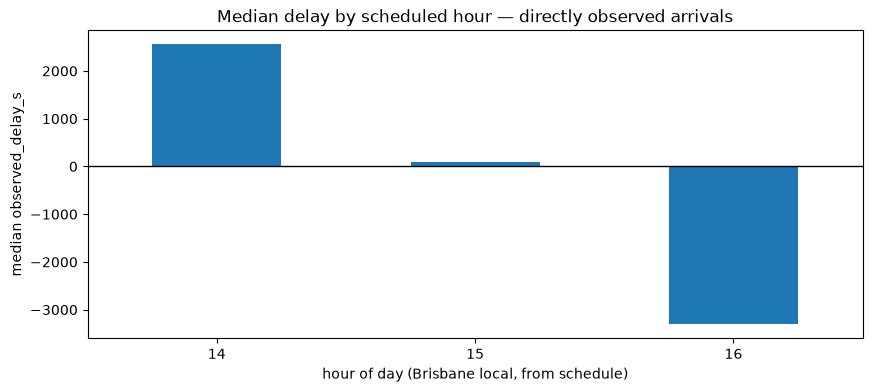

In [4]:
"""Secondary check: median delay by hour of day (directly observed).

Expect delays to grow through the peaks. With only a slice of the day
collected so far this is indicative, not conclusive.
"""

by_hour = (
    observed.groupby("hour_of_day")["observed_delay_s"]
    .agg(["median", "count"])
    .rename(columns={"median": "median_delay_s", "count": "n"})
)

ax = by_hour["median_delay_s"].plot(
    kind="bar", figsize=(10, 4), rot=0, edgecolor="none"
)
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("hour of day (Brisbane local, from schedule)")
ax.set_ylabel("median observed_delay_s")
ax.set_title("Median delay by scheduled hour — directly observed arrivals")
by_hour

## Caveats on this snapshot

1. **Cold-start imputation**: every pipeline (re)start re-imputes the already-
   passed stops of in-flight trips with the current timestamp, inflating
   imputed delays (ADR 0011 documents the restart trade-off). Deterministic
   `event_id`s make these harmless duplicates once dbt dedups downstream.
2. **Short window**: hours of data, not the 7+ days docs/DATA.md wants before
   training. Hour-of-day and weekday patterns are not yet meaningful.
3. **`is_school_day` / `is_public_holiday` are null** until the Queensland
   calendar CSVs land (flagged spec gap, deferred to Phase 3).
4. Trips cancelled mid-flight and `did_not_observe` stops are absent by
   design — they are excluded from training rather than given fake labels.